In [ ]:
# %load loop.py
from typing import Union
import time

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation, PillowWriter

import numpy as np
from opensimplex.internals import _noise4
from opensimplex.api import DEFAULT_SEED
from opensimplex.internals import _init
import opensimplex as osim


import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import json
from scipy.fft import fft, ifft, fftfreq

%matplotlib notebook

try:
    from numba import njit, prange
except ImportError:
    prange = range

    def njit(*args, **kwargs):  # pylint: disable=unused-argument
        def wrapper(func):
            return func

        return wrapper


try:
    from numba_progress import ProgressBar
except ImportError:
    ProgressBar = None
    
    
def progress_bar_wrapper(
    noise_fun: callable,
    noise_kwargs: list,
    verbose: bool = True,
    total: int = 1,
):
    if verbose:
        print(f"{'Generating noise...':30s}")
        tick = time.perf_counter()

    if (ProgressBar is None) or (not verbose):
        out = noise_fun(**noise_kwargs)
    else:
        with ProgressBar(total=total, dynamic_ncols=True) as numba_progress:
            out = noise_fun(**noise_kwargs, progress_hook=numba_progress)

    if verbose:
        print(f"done in {(time.perf_counter() - tick):.2f} s")

    return out

    
    
@njit(
    cache=True,
    parallel=True,
    nogil=True,
)
def _polar_loop_rectangle(
    N_polar: int,
    N_rect_x: int,
    N_rect_y: int,
    step_polar: float,
    step_rect_x: float,
    step_rect_y: float,
    dtype: type,
    perm: np.ndarray,
    progress_hook: Union[ProgressBar, None] = None,
) -> np.ndarray:
    noise = np.empty((N_polar, N_rect_y, N_rect_x), dtype=dtype)
    radius = N_polar * step_polar / (2 * np.pi)
    factor = 2 * np.pi / N_polar

    # Polar loop
    for idx_t in prange(N_polar):
        t = idx_t * factor
        t_cos = radius * np.cos(t)
        t_sin = radius * np.sin(t)

        # Linear traversal y
        for idx_y in prange(N_rect_y):
            y = idx_y * step_rect_y

            # Linear traversal x
            for idx_x in prange(N_rect_x):
                x = idx_x * step_rect_x
                noise[idx_t, idx_y, idx_x] = _noise4(x, y, t_sin, t_cos, perm)

        if progress_hook is not None:
            progress_hook.update(1)

    return noise


@njit(
    cache=True,
    parallel=True,
    nogil=True,
)
def _elliptical_loop_rectangle(
    N_polar: int,
    N_rect_x: int,
    N_rect_y: int,
    step_polar: float,
    step_rect_x: float,
    step_rect_y: float,
    dtype: type,
    perm: np.ndarray,
    progress_hook: Union[ProgressBar, None] = None,
) -> np.ndarray:
    noise = np.empty((N_polar, N_rect_y, N_rect_x), dtype=dtype)
    a = N_polar * step_polar / (2 * np.pi)      # semi-major axis
    b = a * 0.75                                 # semi-minor axis (adjust to control ellipticity)
    omega = 10*2 * np.pi / N_polar                # base angular frequency
    phi_rate = 0.022                             # precession rate in radians per step

    # Polar loop
    for idx_t in prange(N_polar):
        t = idx_t * omega
        phi = idx_t * phi_rate                 # precession angle

        # Precessing elliptical coordinates
        cos_t, sin_t = np.cos(t), np.sin(t)
        cos_phi, sin_phi = np.cos(phi), np.sin(phi)

        # Rotated ellipse
        t_cos = a * cos_t * cos_phi - b * sin_t * sin_phi
        t_sin = a * cos_t * sin_phi + b * sin_t * cos_phi

        # Linear traversal y
        for idx_y in prange(N_rect_y):
            y = idx_y * step_rect_y

            # Linear traversal x
            for idx_x in prange(N_rect_x):
                x = idx_x * step_rect_x
                noise[idx_t, idx_y, idx_x] = _noise4(x, y, t_sin, t_cos, perm)

        if progress_hook is not None:
            progress_hook.update(1)

    return noise




def looping_animated_2D_image(
    N_frames: int = 200,
    N_pixels_x: int = 1000,
    N_pixels_y: Union[int, None] = None,
    t_step: float = 0.1,
    x_step: float = 0.01,
    y_step: Union[float, None] = None,
    dtype: type = np.double,
    seed: int = DEFAULT_SEED,
    verbose: bool = True,
) -> np.ndarray:
    """Generates a stack of seamlessly-looping animated 2D raster images drawn
    from 4D OpenSimplex noise.

    The first two OpenSimplex dimensions are used to describe a plane that gets
    projected onto a 2D raster image. The last two dimensions are used to
    describe a circle in time.

    Args:
        N_frames (`int`, default = 200)
            Number of time frames

        N_pixels_x (`int`, default = 1000)
            Number of pixels on the x-axis

        N_pixels_y (`int` | `None`, default = `None`)
            Number of pixels on the y-axis. When set to None `N_pixels_y` will
            be set equal to `N_pixels_x`.

        t_step (`float`, default = 0.1)
            Time step

        x_step (`float`, default = 0.01)
            Spatial step in the x-direction

        y_step (`float` | `None`, default = `None`)
            Spatial step in the y-direction. When set to None `y_step` will be
            set equal to `x_step`.

        dtype (`type`, default = `numpy.double`)
            Return type of the noise array elements. To reduce the memory
            footprint one can change from the default `numpy.double` to e.g.
            `numpy.float32`.

        seed (`int`, default = 3)
            Seed value for the OpenSimplex noise

        verbose (`bool`, default = `True`)
            Print 'Generating noise...' to the terminal? If the `numba_progress`
            package is present a progress bar will also be shown.

    Returns:
        The 2D image stack as 3D array [time, y-pixel, x-pixel] containing the
        OpenSimplex noise values as floating points. The output is garantueed to
        be in the range [-1, 1], but the exact extrema cannot be known a-priori
        and are probably quite smaller than [-1, 1].
    """

    perm, _ = _init(seed)

    out = progress_bar_wrapper(
        noise_fun=_elliptical_loop_rectangle,
        noise_kwargs={
            "N_polar": N_frames,
            "N_rect_x": N_pixels_x,
            "N_rect_y": N_pixels_y if N_pixels_y is not None else N_pixels_x,
            "step_polar": t_step,
            "step_rect_x": x_step,
            "step_rect_y": y_step if y_step is not None else x_step,
            "dtype": dtype,
            "perm": perm,
        },
        verbose=verbose,
        total=N_frames,
    )

    return out





In [4]:
out = looping_animated_2D_image(N_frames=100,N_pixels_x=256, t_step = 0.015, x_step = 0.05)

Generating noise...           
done in 2.16 s


In [5]:
if True:
    noise_3d = np.where(out > 0, np.pi/2, -np.pi/2)

In [6]:
out.shape

(100, 256, 256)

In [7]:
%matplotlib notebook

def make_detector_movie(filename, imgs, scan_var,period, fig, ax, fps,scale='log',clims = [0,10]):
    # Makes an animation of the detector images stored in `imgs`.
    # `fig` and `ax` are the Figure and Axes objects used to plot each movie frame
    # `filename` is the name of the output .gif file
    # `clims` is the colormap range
    # `fps` is the frame rate (frames per second) of the movie
    Nt = imgs.shape[0]
    
    if scale=='log':
        im = ax.imshow(imgs[0,:,:]+1, cmap='nipy_spectral',norm=LogNorm(clims[0], clims[1]))
    if scale=='gray':
        im = ax.imshow(imgs[0,:,:],cmap = 'gray',clim = (clims[0],clims[1]))
    else:
        im = ax.imshow(imgs[0,:,:], cmap='nipy_spectral',clim = (clims[0],clims[1]))
    
    fig.colorbar(im,ax=ax)
    
    def func(ii):
        im.set_data(imgs[ii,:,:])
        ax.set_title('Time = ' + str(np.around(period*scan_var[ii-1],2)) + ' seconds')
        return im
    
    anim = FuncAnimation(fig, func, frames=range(1,Nt))
    anim.save(filename + '.gif', writer=PillowWriter(fps=fps))

<IPython.core.display.Javascript object>


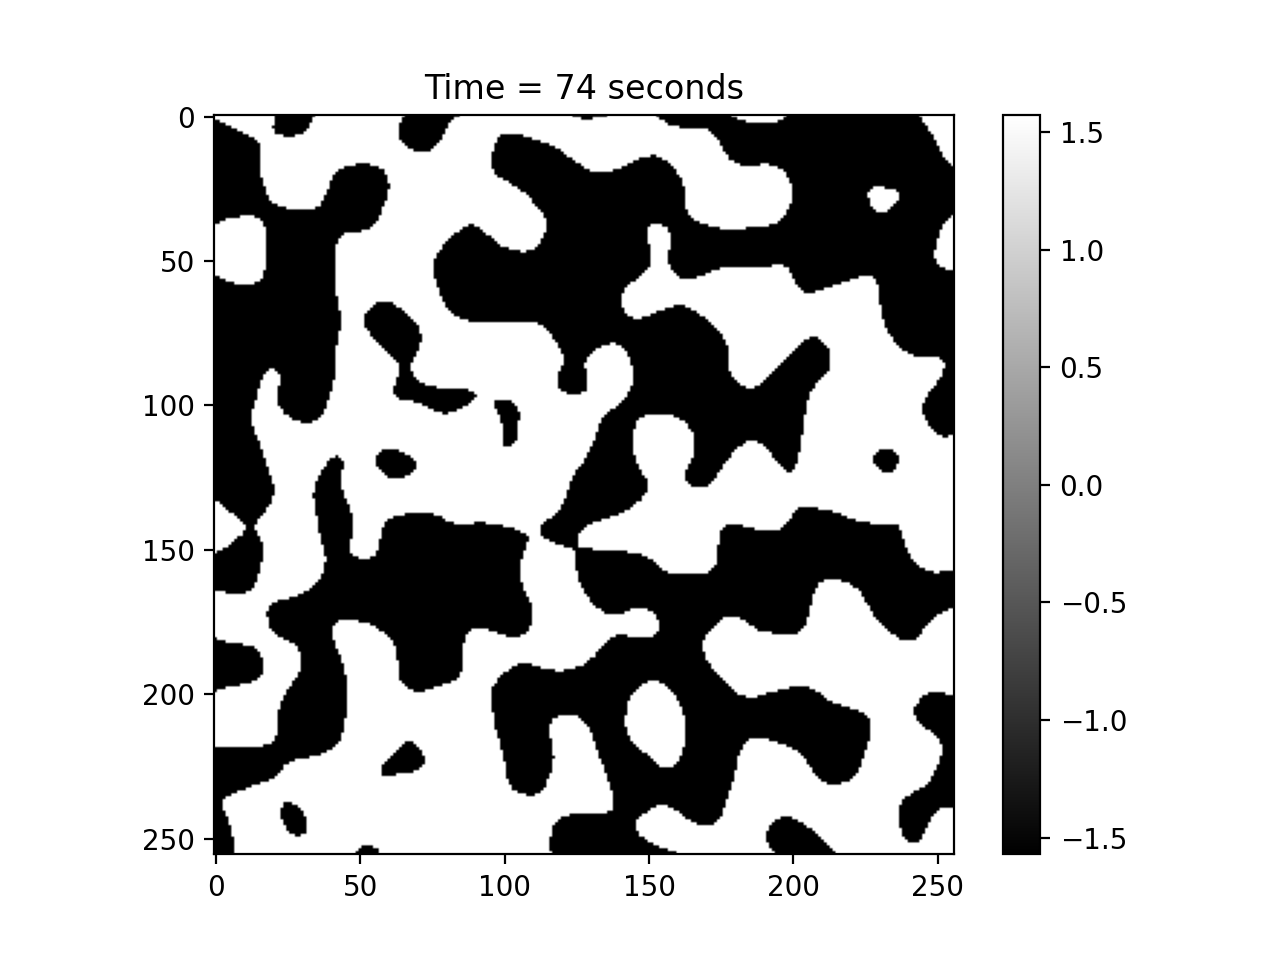

In [8]:
fig,ax = plt.subplots()
make_detector_movie('test',noise_3d,np.arange(0,100),period=1,fig=fig,ax=ax,fps=5,scale='gray',clims=[-np.pi/2,np.pi/2])

In [138]:
# Seed the noise generator for consistent results
osim.seed(0)

# Generate 2D noise
size = 10
width, height = 256, 256
time_steps = 1000

Binary = True

# Generate 3D noise
noise_3d = np.zeros((time_steps, height, width))
for t in range(time_steps):
    for y in range(height):
        for x in range(width):
            noise_3d[t][y][x] = osim.noise3(x/size, y/size, t/(50*size))

#Convert to phase array
#noise_3d = np.pi*noise_3d/2
#noise_3d = (noise_3d+1)/2

if Binary:
    noise_3d = np.where(noise_3d > 0, np.pi/2, -np.pi/2)

<IPython.core.display.Javascript object>


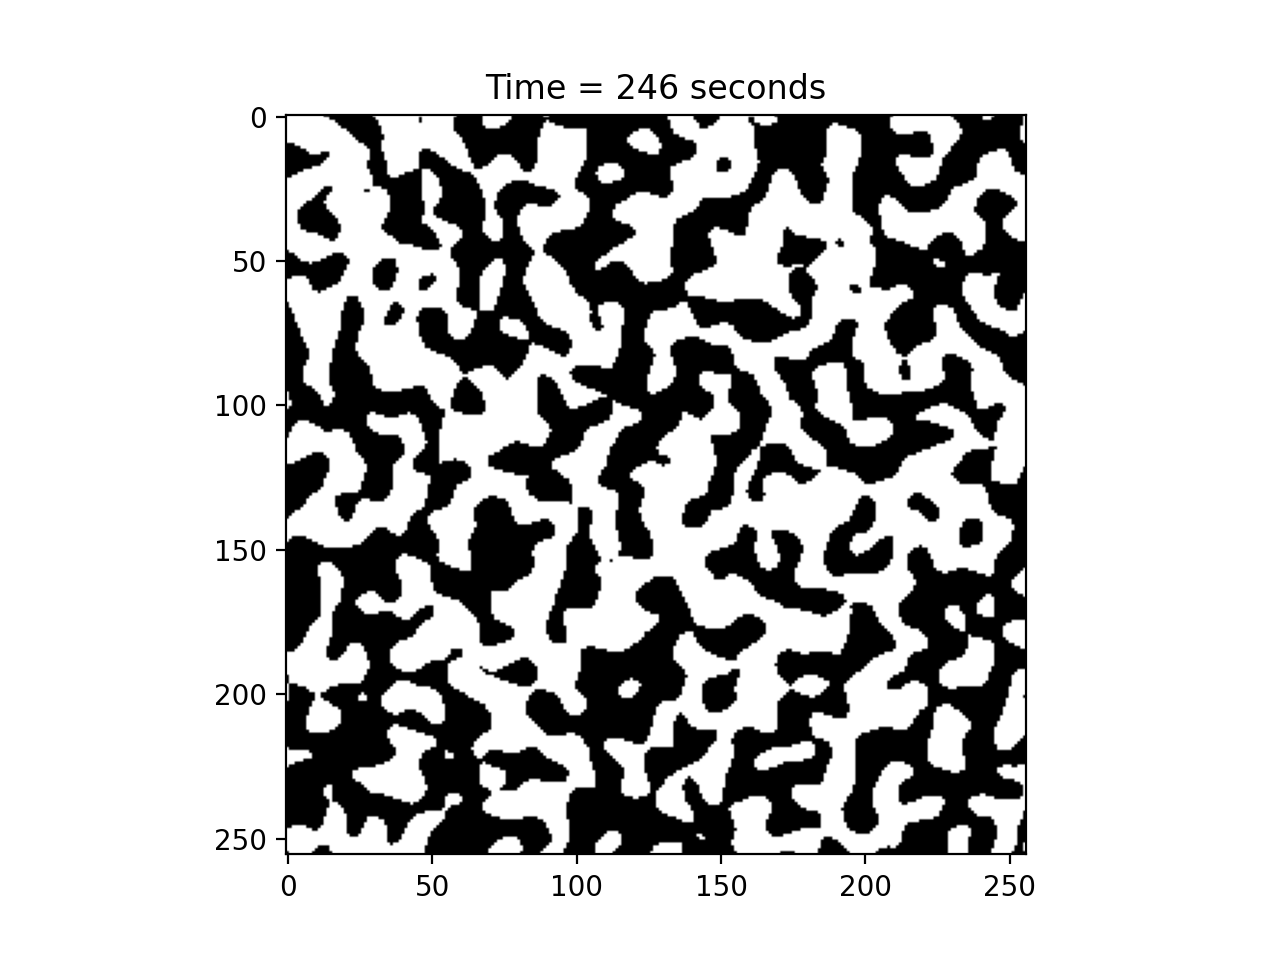

In [139]:
fig,ax = plt.subplots()
make_detector_movie('test',noise_3d,np.arange(0,1000),period=1,fig=fig,ax=ax,fps=5,scale='gray',clims=[-np.pi/2,np.pi/2])

<IPython.core.display.Javascript object>


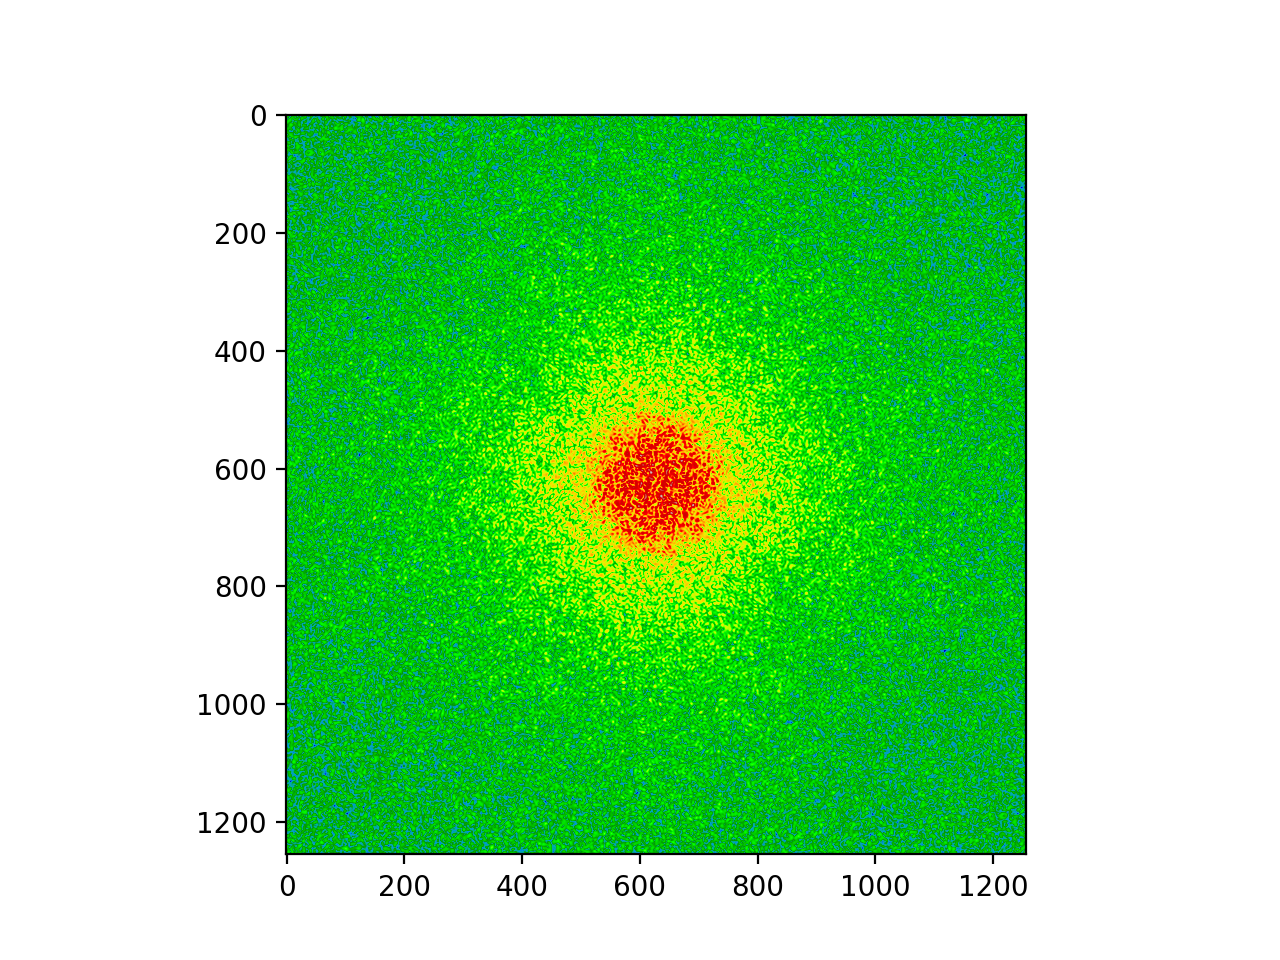

<function matplotlib.pyplot.show(*, block=None)>

In [140]:
# Linear dimension of the nxn array to be used.
# The user can change this number.
#n = 500
n = noise_3d.shape[1]

# Number of samples (in one dimension) per speckle. 
# The user can change this number.
#k = 100
pad = 1000

# Dynamical Parameters
timesteps = 1000 # Number of Time Steps
dt = 0.25 # Time Step Size
D = 0.01 # Diffusion coefficient
dx = 1 # Grid spacing

# Generate an n/k x n/k array of random phasors
#start =  np.exp(1j*2*np.pi*noise_3d[0,:,:]) #np.exp(1j*2*np.pi*np.random.random((n//k,n//k)))
start =  np.exp(1j*noise_3d[0,:,:]) #np.exp(1j*2*np.pi*np.random.random((n//k,n//k)))

# Pad the phasor array with zeros. The scattering spot is a square of size n/k x n/k.
scatteredarray = np.pad(start,(0,pad),mode='constant')

# Find the FFT of the padded array. This is the speckle field in the observation plane. 
specklefield = np.fft.fftshift((np.fft.fft2(scatteredarray)))

# Find the intensity of the observed speckle field.
speckleintensity = np.abs(specklefield)**2


# Plotting
%matplotlib notebook

fig,ax = plt.subplots()
ax.imshow(np.log(speckleintensity+1),'nipy_spectral')
plt.show

In [141]:
n = noise_3d.shape[1]
time_steps = noise_3d.shape[0]
# Number of samples (in one dimension) per speckle. 
# The user can change this number.
#k = 100
pad = 1000


specklemovie = np.zeros((time_steps,speckleintensity.shape[0],speckleintensity.shape[1]))

for i,n3d in enumerate(noise_3d):
    

    # Generate an n/k x n/k array of random phasors
    #start =  np.exp(1j*2*np.pi*noise_3d[0,:,:]) #np.exp(1j*2*np.pi*np.random.random((n//k,n//k)))
    speckle =  np.exp(1j*n3d) #np.exp(1j*2*np.pi*np.random.random((n//k,n//k)))

    # Pad the phasor array with zeros. The scattering spot is a square of size n/k x n/k.
    scatteredarray = np.pad(speckle,(0,pad),mode='constant')

    # Find the FFT of the padded array. This is the speckle field in the observation plane. 
    specklefield = np.fft.fftshift((np.fft.fft2(scatteredarray)))

    # Find the intensity of the observed speckle field.
    specklemovie[i,:,:] += np.abs(specklefield)**2

<IPython.core.display.Javascript object>


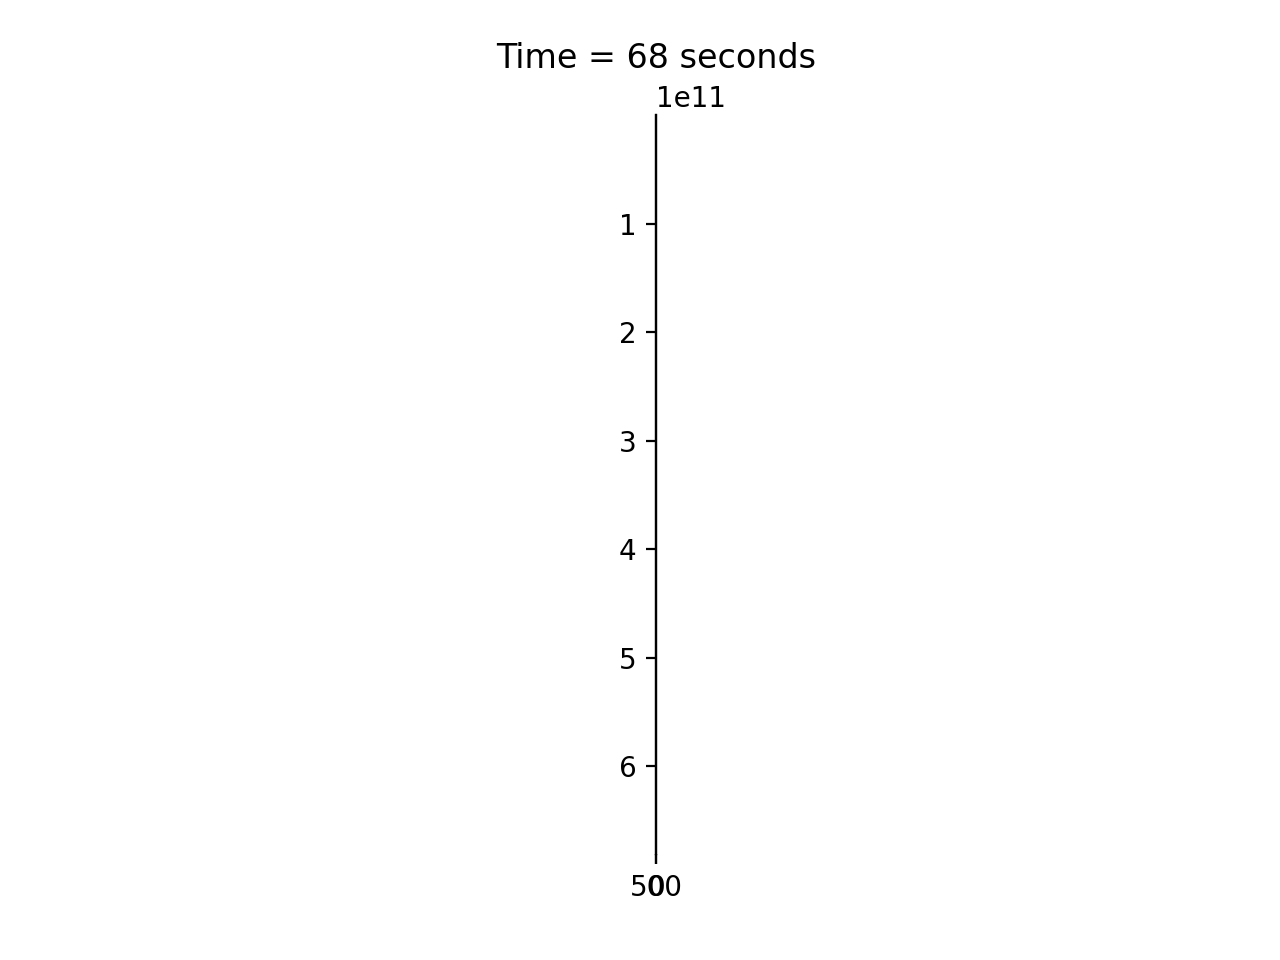

In [142]:
fig,ax = plt.subplots()
crop = 300
roi = [specklemovie.shape[1]//2-crop,specklemovie.shape[1]//2+crop,specklemovie.shape[2]//2-crop,specklemovie.shape[2]//2+crop]
make_detector_movie('test_speckle',np.log(specklemovie[:,roi[0]:roi[1],roi[2]:roi[3]]+1),np.arange(time_steps),period=1,fig=fig,ax=ax,fps=5,scale='nipy_spectral',clims=[5,20])

In [143]:
plt.plot(np.sum(np.sum(specklemovie[:,roi[0]:roi[1],roi[2]:roi[3]],axis=0),axis=0))

In [144]:
det = specklemovie

<IPython.core.display.Javascript object>


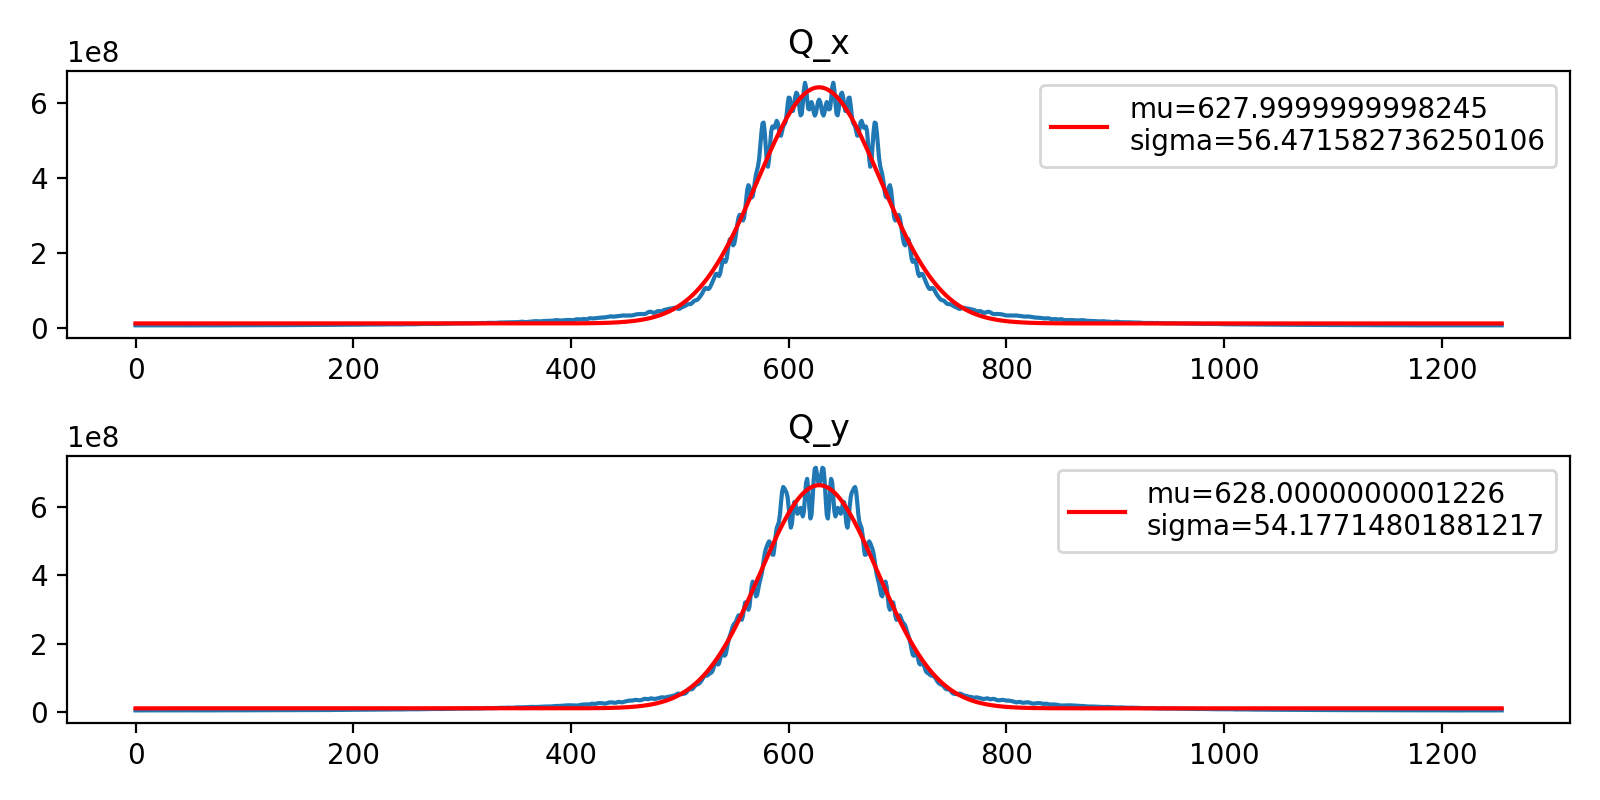

In [145]:
#Central Slice
#central_slice = det.shape[0]//2

### Sum data along both axes for fitting ###
y1 = np.sum(np.mean(det[:,:,:],axis=0),axis=0)
x1 = np.arange(y1.shape[0])

y2 = np.sum(np.mean(det[:,:,:],axis=0),axis=1)
x2 = np.arange(y2.shape[0])

popt1, pcov1 = curve_fit(gaussian, x1, y1, p0=[np.max(y1), np.argmax(y1) , 1, np.min(y1[np.nonzero(y1)])])
popt2, pcov2 = curve_fit(gaussian, x2, y2, p0=[np.max(y2), np.argmax(y2) , 1, np.min(y2[np.nonzero(y2)])])

### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 4))  # 2 rows, 1 column

# Plot on the first axis
axs[0].plot(y1)
axs[0].plot(x1, gaussian(x1, *popt1), label='mu={}\nsigma={}'.format(popt1[1],popt1[2]), color='red')
axs[0].set_title('Q_x')
axs[0].legend()

# Plot on the second axis
axs[1].plot(y2)
axs[1].plot(x2, gaussian(x2, *popt2), label='mu={}\nsigma={}'.format(popt2[1],popt2[2]), color='red')
axs[1].set_title('Q_y')
axs[1].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [146]:
#Crop Size
#number of standard deviations from peak
Xv = 5
Xh = 5

#Peak Locations
hCen = int(np.rint(popt1[1]))
vCen = int(np.rint(popt2[1]))

#hCen = int(np.rint(popt[1]))
#vCen = int(np.rint(popt[2]))

#print(hCen)
#print(vCen)

#Standard Deviations
hSig = int(np.rint(popt1[2]))
vSig = int(np.rint(popt2[2]))

#hSig = int(np.rint(popt[3]))
#vSig = int(np.rint(popt[4]))

#angTilt = popt[5] #tilt in the distribution


#Set ROI
roi = [int(vCen-Xv*vSig),int(vCen+Xv*vSig),int(hCen-Xh*hSig),int(hCen+Xh*hSig)] #vertical_1, vertical_2, horizontal_1, horizontal_2

print(roi)    
#Take subset of detector
det_cropped = det[:,roi[0]:roi[1],roi[2]:roi[3]]
#det_corr_cropped = det_corr[:,roi[0]:roi[1],roi[2]:roi[3]]

[358, 898, 348, 908]


<IPython.core.display.Javascript object>


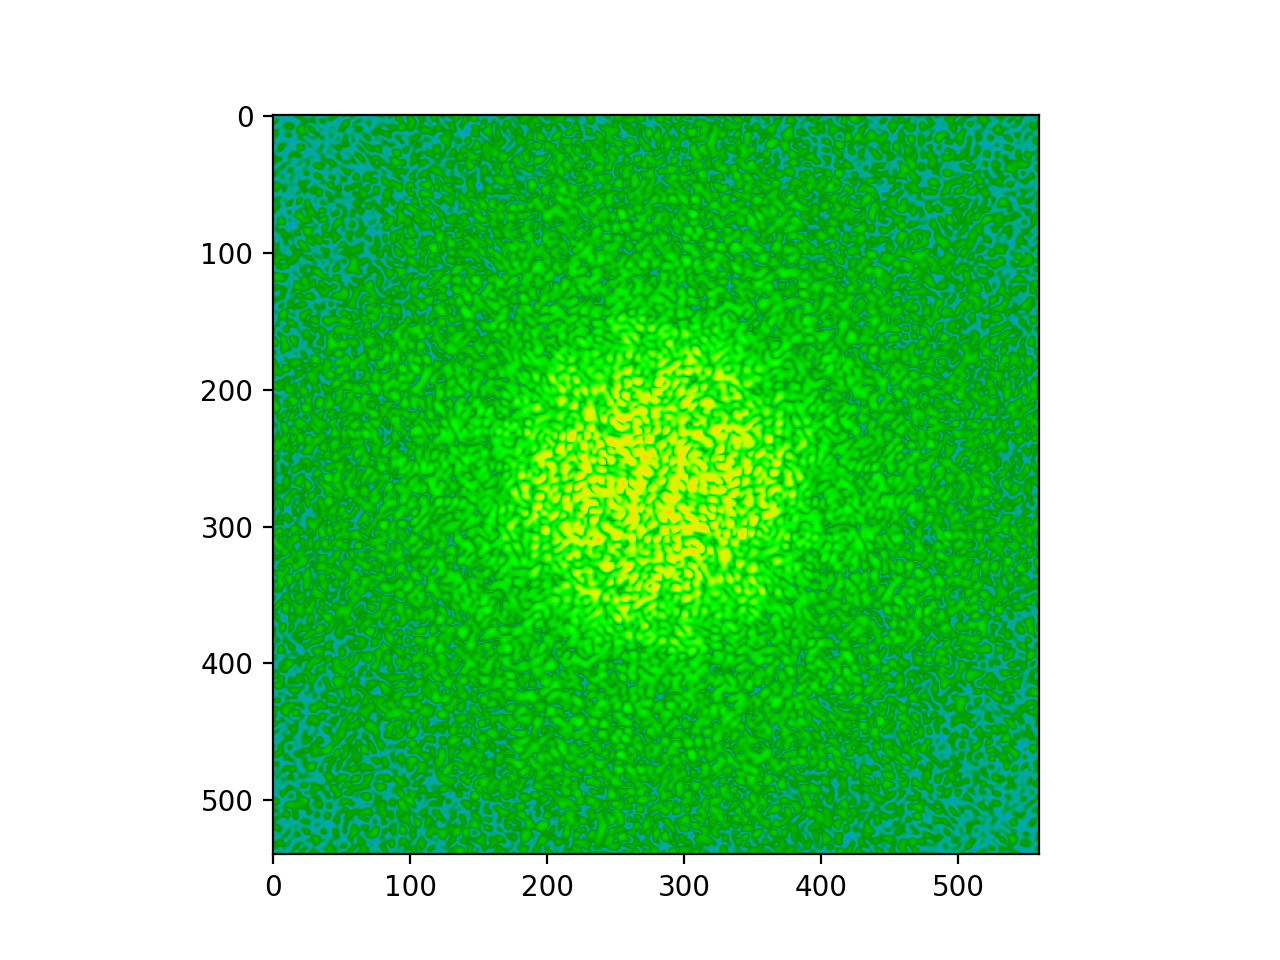

In [147]:
#Plot cropped image
fig, ax = plt.subplots()

ax.imshow(np.sum(det_cropped[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=100000000000))

In [ ]:
maskSize = 4
numRings = 15
numSlices = 1
tol = 0.02 # Percentage tolerance for converging to ring partition
res = 0.0001 # Resolution for ring size increments
tilt = 0

#hSig = np.mean(POPT[:,3])
#VSig = np.mean(POPT[:,4])

#Create Elliptical Masks. Non-masked regions are -1
masks,ringWidths = const_int_mask(det_cropped,hSig,vSig,maskSize,numRings,numSlices,-tilt,tol,res) #Create the masks of equal intensity

#For Plotting. Change -1s to 0s
masks_plot = np.copy(masks)
#masks_plot[masks_plot==-1] = 0

for i in range(masks_plot.shape[0]):
    masks_plot[i,:,:] = (i+1)*masks_plot[i,:,:]

#Sum of the masks for a single mask image
mask_sum = np.sum(masks_plot,axis=0)

<IPython.core.display.Javascript object>


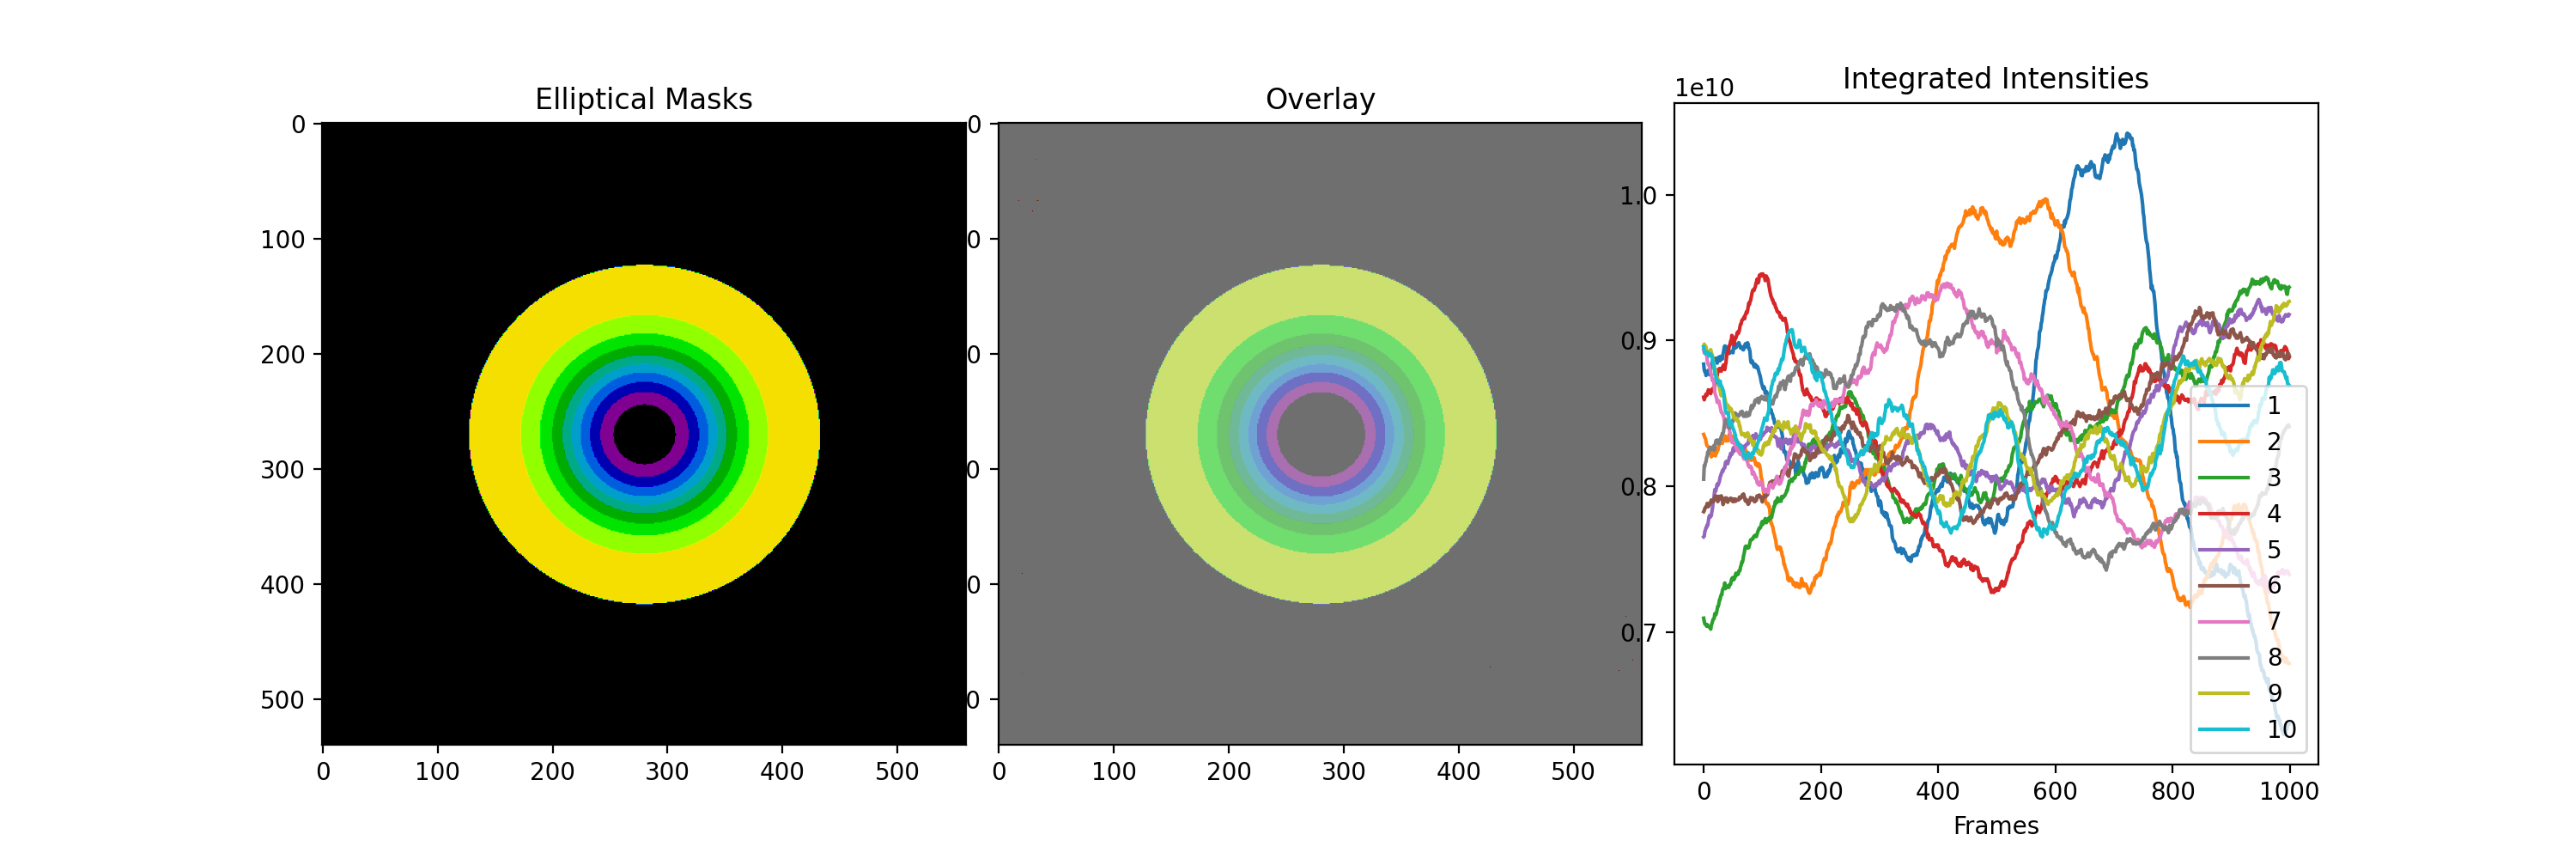

<function matplotlib.pyplot.show(*, block=None)>

In [149]:
### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
#print(det.shape)

#Plot the Masks alone, with labels
axs[0].imshow(mask_sum,'nipy_spectral',clim=(1,numRings*numSlices+3.5))
axs[0].set_title('Elliptical Masks')

#Plot the masks overlayed on the detector image
# Display the first image of mask sum
axs[1].imshow(mask_sum-1, cmap='nipy_spectral',clim =(1,numRings*numSlices+3), alpha=1)
# Overlay the second image with a 'plasma' color scale and some transparency
axs[1].imshow(np.sum(det_cropped[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35),alpha=0.55)
axs[1].set_title('Overlay')


#Plot the integrated intensity of each mask region
#i=0
for i,m in enumerate(masks): 
    axs[2].plot(np.sum(det_cropped[:,m==1],axis=1),label='{}'.format(i+1))
    #i+=1
axs[2].set_title('Integrated Intensities')
axs[2].set_xlabel('Frames')
axs[2].legend()

plt.subplots_adjust(wspace=0.05, hspace=0.4)
plt.show

In [155]:
frameSpacing = 1
#XPCS fitting parameters
a = 1
tt1 = 1
tt2 = 100
b1 = 1
b2 = 1
trunc = -2 # Cut last few points from fit
Double_Exp = False


#Calculate the G2 autocorrelations for the entire image
mask = np.ones(det_cropped.shape[1:])

#Delays per level. Increase for more sampling
dpl = 4

#IF are intensities future, intensities past. Used to normalize g2
sumI,G2,IF,IP,_ = g2calc(det_cropped[:,:,:],mask,dpl)

# Calculate Frame Spacing
nframes = det_cropped.shape[0]
delay = frameSpacing * finddelays(nframes,dpl,1)

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_91788/2497901081.py:2: RuntimeWarning: divide by zero encountered in divide
  g2 = np.mean(G2[:,masks[mi,:,:]==1])/(np.mean(IF[:, masks[mi,:,:]==1],axis=1)*np.mean(IP[:, masks[mi,:,:]==1],axis=1))


<IPython.core.display.Javascript object>


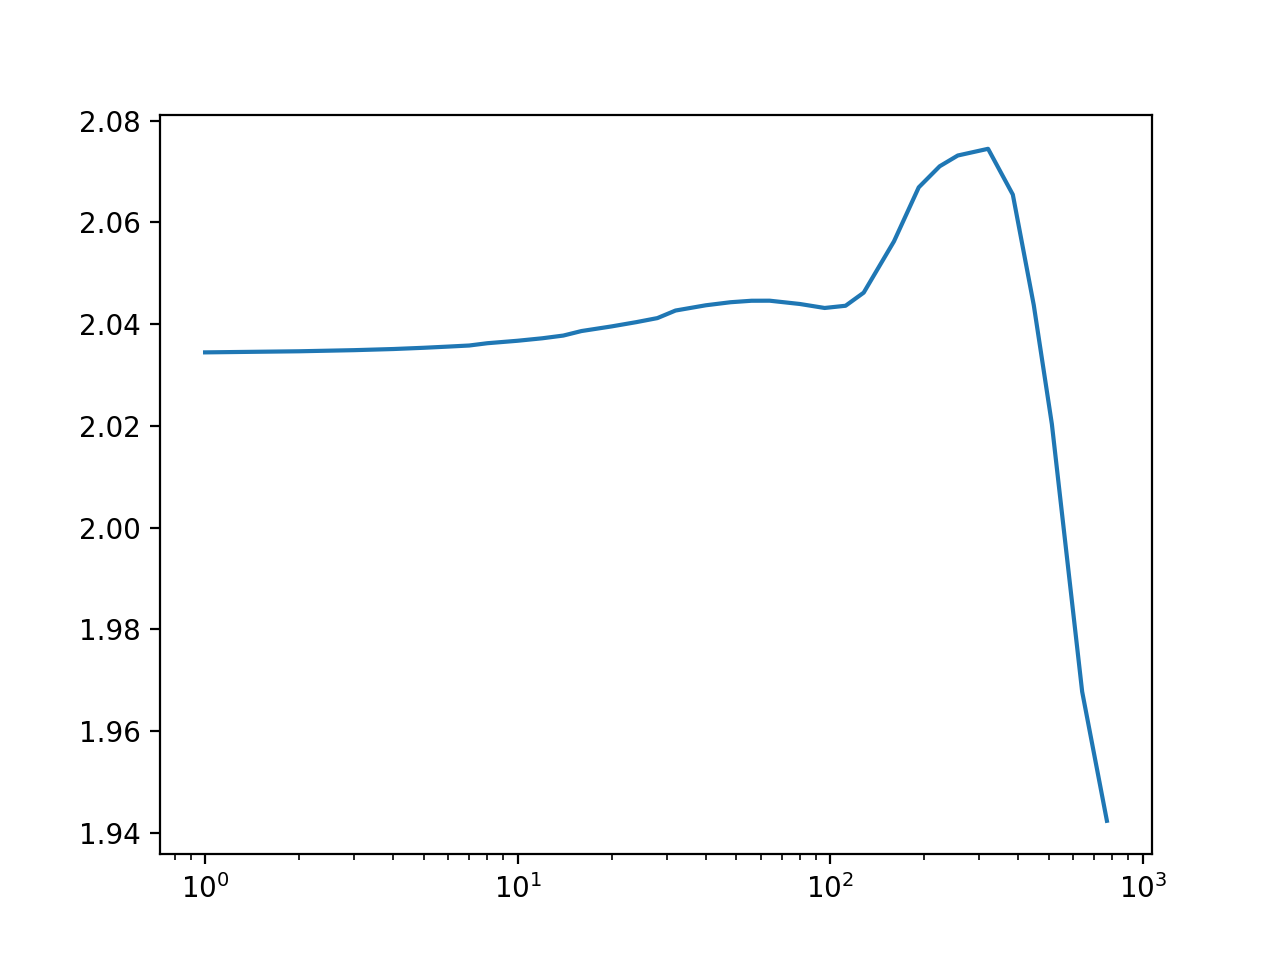

In [159]:
mi = 9
g2 = np.mean(G2[:,masks[mi,:,:]==1])/(np.mean(IF[:, masks[mi,:,:]==1],axis=1)*np.mean(IP[:, masks[mi,:,:]==1],axis=1))
fig,ax = plt.subplots()
ax.semilogx(delay[0,:],g2[:-1])

<IPython.core.display.Javascript object>


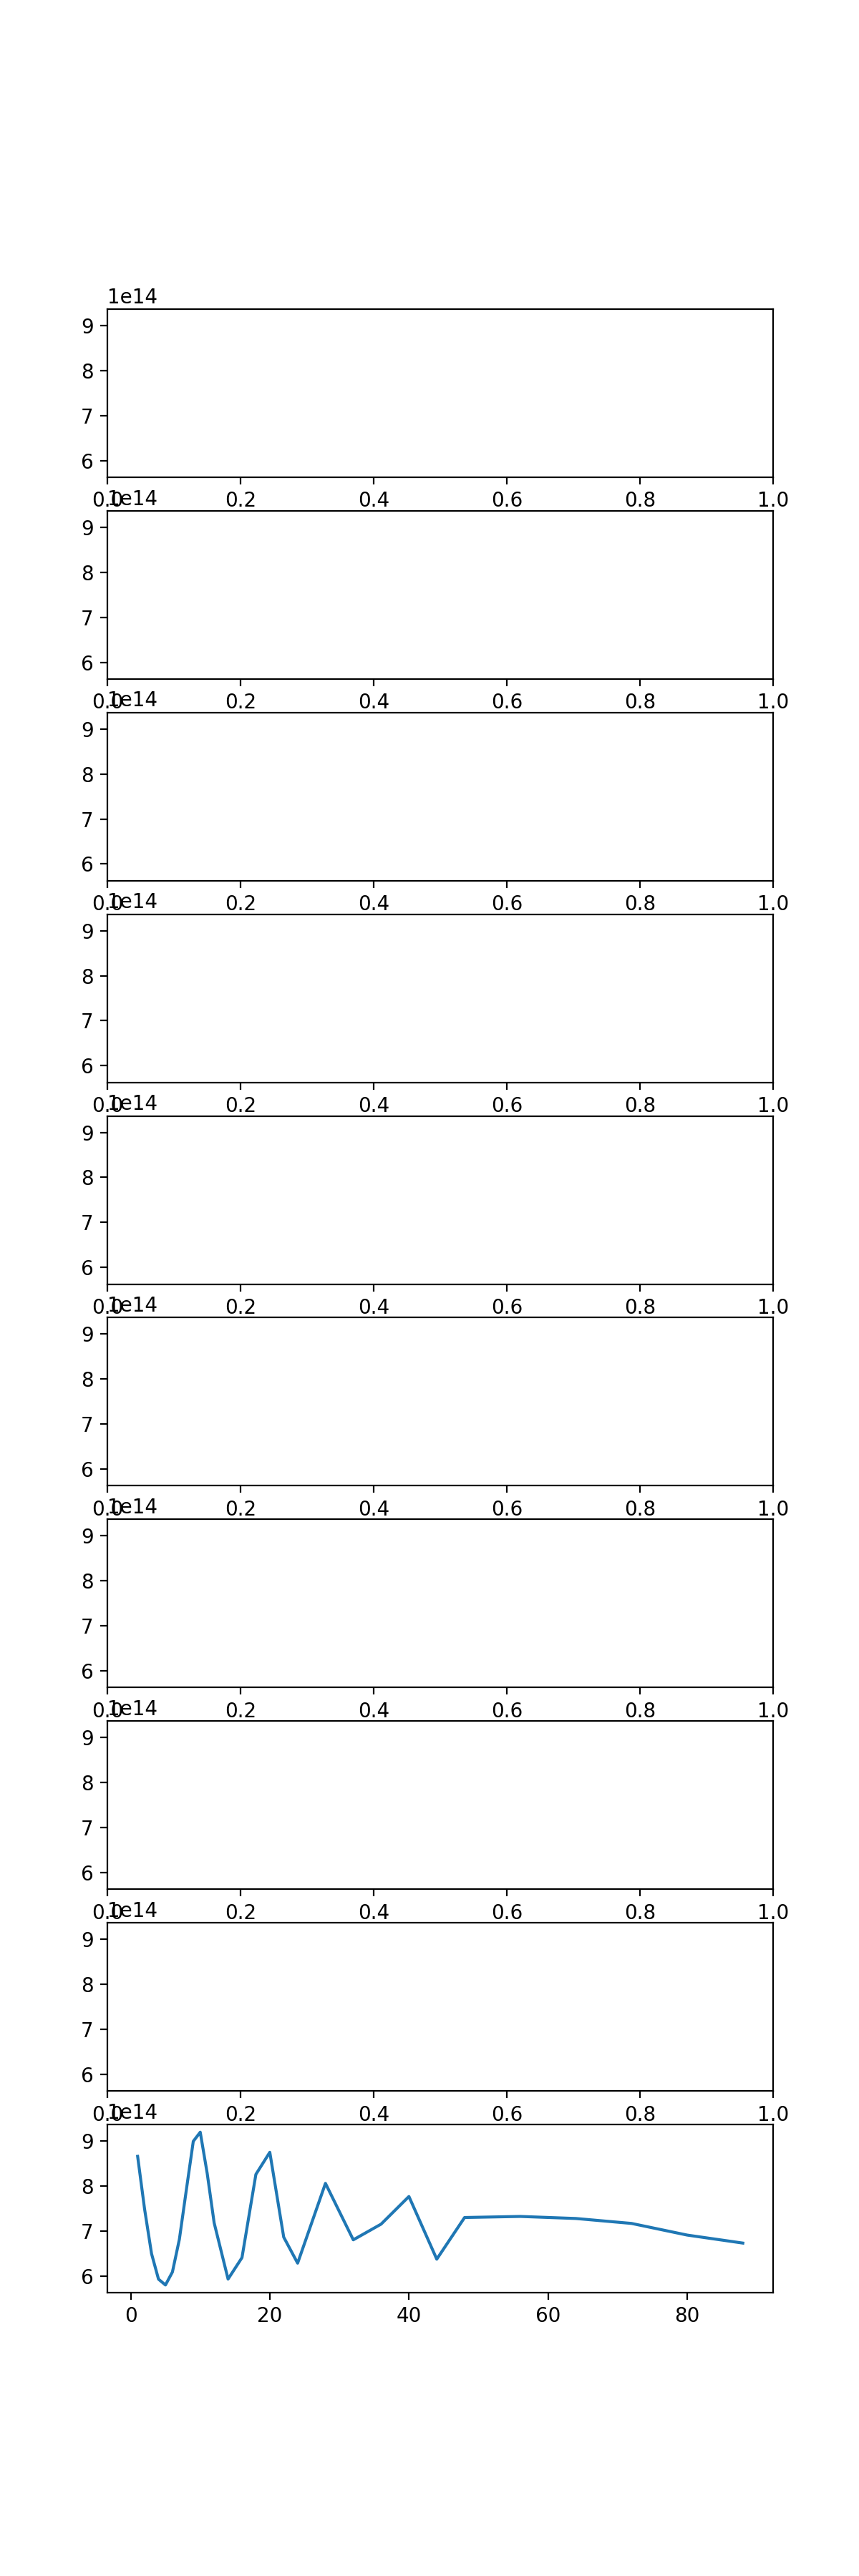

ValueError: array must not contain infs or NaNs

In [63]:
#Used for stuff
#if timeBatch == -1:
 #   timeBatch = nFrames*frameSpacing

#Results Arrays
G2_result = np.zeros((masks.shape[0],delay.shape[1]))
G2_error = np.zeros((masks.shape[0],delay.shape[1]))




if not Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])

    betas = np.zeros(masks.shape[0]) #Assumes one betas
    betas_err = np.zeros(masks.shape[0]) #Assumes one betas

    taus = np.zeros(masks.shape[0]) #Assumes one relaxation times
    taus_err = np.zeros(masks.shape[0]) #Assumes relaxation times
    
if Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])
    
    aas = np.zeros(masks.shape[0])
    aas_err = np.zeros(masks.shape[0])

    betas = np.zeros((masks.shape[0],2)) #Assumes two betas
    betas_err = np.zeros((masks.shape[0],2)) #Assumes two betas
    taus = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    taus_err = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    
    
    #aas = np.zeros(masks.shape[0])
    #aas_err = np.zeros(masks.shape[0])


if numSlices == 1 and numRings>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(6,18), sharey=True) #FFT check
if numRings == 1 and numSlices>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(24,6), sharey=True) #FFT check
#else:
#    fig,axs = plt.subplots(numRings,numSlices,figsize=(9.75,9), sharey=True)

# Indices for plotting
i=0
j=0

#Array for truncating fits
truncs = [trunc]*numRings*numSlices

for mm,m in enumerate(masks):
    
    #Used to single out specific scans for truncating the last few points
    if True:
        if mm==0:
            truncs[mm] = trunc
        if mm==1:
            truncs[mm] = trunc
    
    #Used to not truncate
    if truncs[mm] == 0:
        truncs[mm] = G2_result.shape[1]
        
    # Last bit of filtering 
    G2_masked = G2[:,m==1]

    # Removes the detector borders
    hot_pixel_mask = G2_masked[0,:] < 10**(10) 
    
    # Average and normalize g2s
    if np.abs(G2_masked.shape[0]-delay.shape[1])==0:
        last_index = G2_masked.shape[0]
    if np.abs(G2_masked.shape[0]-delay.shape[1])>0:
        last_index = -np.abs(G2_masked.shape[0]-delay.shape[1])

    # Initialize output arrays
    g2dummy = np.zeros_like(G2_masked)

    # Compute partition normalization factor (avoiding division by zero)
    part_norm = np.mean(IF[:, m == 1][:, hot_pixel_mask == 1],axis=1) * np.mean(IP[:, m == 1][:, hot_pixel_mask == 1], axis=1)

    # Normalize G2
    g2dummy = np.divide(G2_masked, part_norm[:, np.newaxis], out=np.full_like(G2_masked, np.nan), where=part_norm[:, np.newaxis] != 0)

    # Compute mean and standard error over the mask
    valid_pixels = hot_pixel_mask == 1

    G2_result[mm, :] += np.mean(g2dummy[:, valid_pixels][:last_index], axis=1)
    G2_error[mm, :] += np.std(g2dummy[:, valid_pixels][:last_index], axis=1) / np.sqrt(np.sum(valid_pixels))
    
    
    
    
    
    
    #G2_result[mm,:] += np.mean(G2_corr/np.mean(det_corr[:,m==1][:,hot_pixel_mask==1])**2,axis=1)[:last_index] 
    # G2_error[mm,:] += np.std(G2_corr/np.mean(det_corr[:,m==1][:,hot_pixel_mask==1])**2,axis=1)[:last_index]/np.float32(np.sqrt(G2_corr.shape[1]))
    #print(hot_mask)
    #G2_corr = G2_masked[:,hot_pixel_mask==1]
    
    #print(G2_corr.shape)
    #print((IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1]).shape)
    

    """""""""
    g2dummy = np.zeros(G2_masked.shape)
    
    for td in range(G2_result.shape[1]):

        g2dummy[td,:] += G2_masked[td,:]/(np.mean(IF[td,m==1][hot_pixel_mask==1])*np.mean(IP[td,m==1][hot_pixel_mask==1])) #[:last_index] 
 
        G2_result[mm,td] += np.mean(g2dummy[td,:][hot_pixel_mask==1])
        G2_error[mm,td] += np.std(g2dummy[td,:][hot_pixel_mask==1])/np.float32(np.sqrt(np.size(g2dummy[td,:][hot_pixel_mask==1])))
    """""""""
    #G2_result[j,:] += np.mean(G2_corr,axis=1)[:last_index] /np.mean(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index] 
    #G2_result[j,td] += np.mean(G2_corr,axis=1)/(np.mean(IF[td,m==1][td,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index] 
    
    #G2_error[j,td] += np.std(G2_corr[td,:]/(np.mean(IF[td,m==1][hot_pixel_mask==1])*np.mean(IP[td,m==1][hot_pixel_mask==1])))/np.float32(np.sqrt(G2_corr.shape[1])) #[:last_index]

    #G2_result[j,:] += np.mean(G2_corr/(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1]),axis=1)[:last_index] 
    #G2_error[j,td] += np.std(G2_corr)/np.mean(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index]/np.float32(np.sqrt(G2_corr.shape[1]))

    #print(det_corr[:,m==1][:,hot_pixel_mask==1].shape)
    #print(G2_corr.shape)
               


    
    #Fit Each G2(Q)
    #Initial Guesses
    A = np.max(G2_result[mm,:truncs[mm]])-1

    if not Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,tt1,b1],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],taus[mm-1],betas[mm-1]],bounds=(lower_bounds, upper_bounds))
        
        #Update fit results
        As[j] += popt[0]
        taus[j] += popt[1]
        betas[j] += popt[2]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[j] += errors[0]
        taus_err[j] += errors[1]
        betas_err[j] += errors[2]
         
    if Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,a,tt1,tt2,b1,b2],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],aas[mm-1],taus[mm-1,0],taus[mm-1,1],betas[mm-1,0],betas[mm-1,1]],bounds=(lower_bounds, upper_bounds))

        #Update fit results
        As[j] += popt[0]
        aas[j] += popt[1]
        taus[j,:] += popt[2:4]
        betas[j,:] += popt[4:6]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[j] += errors[0]
        aas_err[j] += popt[1]
        taus_err[j,:] += errors[2:4]
        betas_err[j,:] += errors[4:6]
    
    
    if numSlices == 1:
        #Add to the plots
        axs[j].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[j].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å'.format(dQ[j]))
        
        if not Double_Exp:
            axs[j].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[j].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
            
        axs[j].legend()
        
    if numSlices > 1 and numRings > 1:
        #Add to the plots
        axs[i%numRings,j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[i%numRings,j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[i%numRings,j%numSlices].legend()
        
    if numSlices > 1 and numRings == 1:
        #Add to the plots
        axs[j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[j%numSlices].legend()
    
    """""""""
    #Update fit results
    Cs[j] += popt[0]
    As[j] += popt[1]
    aas[j] += popt[1]
    taus[j,:] += popt[3:5]
    betas[j] += popt[-1]
    
    #Extract errors
    errors = np.sqrt(np.diag(pcov))
    
    Cs_err[j] += errors[0]
    As_err[j] += errors[1]
    aas_err[j] += errors[1]
    taus_err[j,:] += errors[3:5]
    betas_err[j] += errors[-1]
    """""""""
    
    # Ensures each row is corresponds to a ring, each column to a slice. First row is inner most ring
    if j%numSlices == 3:
        i+=1
        
    j+=1
    
    

plt.tight_layout()       
plt.show